# Illustrative control–capability trade-off

All 14 values are illustrative placeholders, not experimental results. The single panel plots the original General ability and Steering performance scores. The x-axis compresses 22–34 by a factor of 0.12; the shaded region is labeled explicitly. All scores, including 32.487 within that interval, remain plotted at their original data coordinates. Outside the shaded region, the x-axis uses an unchanged linear scale. Marker size encodes steering strength.

Run from the repository or `notebooks/`; export PDF first and show an SVG preview.


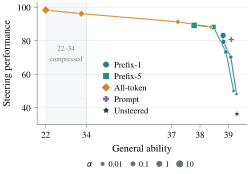

Saved illustrative figure: /home/xzascc/Documents/code/Prefix/figs/steering_tradeoff_7b_toy.pdf


In [1]:
from pathlib import Path
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import SVG, display

DATA = [
    # series, strength, general ability, steering performance

    ("Prefix-1", 10,    38.813, 83.127),
    ("Prefix-1", 1,     38.824, 79.341),
    ("Prefix-1", 0.1,   39.087, 70.214),
    ("Prefix-1", 0.01,  39.286, 48.173),

    ("Prefix-5", 10,    37.791, 89.238),
    ("Prefix-5", 1,     38.476, 88.154),
    ("Prefix-5", 0.1,   38.914, 73.286),
    ("Prefix-5", 0.01,  39.183, 50.127),

    ("All-token", 10,   22.042, 98.317),
    ("All-token", 1,    32.487, 96.124),
    ("All-token", 0.1,  37.216, 91.283),
    ("All-token", 0.01, 38.374, 88.195),

    ("Prompt", None,    39.100, 80.733),
    ("Unsteered", None, 39.300, 36.271),
]

STYLES = {
    "Prefix-1": {"color": "#247BA0", "marker": "o"},
    "Prefix-5": {"color": "#209677", "marker": "s"},
    "All-token": {"color": "#D9822B", "marker": "D"},
    "Prompt": {"color": "#8064A2", "marker": "P"},
    "Unsteered": {"color": "#30343B", "marker": "*"},
}
STRENGTH_SIZES = {0.01: 9, 0.1: 16, 1: 25, 10: 36}
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks").is_dir() and (p / "figs").is_dir())
OUTPUT = ROOT / "figs" / "steering_tradeoff_7b_toy.pdf"

# Keep every score; compress only the displayed distance between 22 and 34.
COMPRESS_START, COMPRESS_END, COMPRESS_FACTOR = 22.0, 34.0, 0.12
COMPRESSED_END = COMPRESS_START + (COMPRESS_END - COMPRESS_START) * COMPRESS_FACTOR


def compress_x(values):
    values = np.asarray(values)
    return np.where(values < COMPRESS_START, values,
                    np.where(values <= COMPRESS_END,
                             COMPRESS_START + (values - COMPRESS_START) * COMPRESS_FACTOR,
                             COMPRESSED_END + values - COMPRESS_END))


def expand_x(values):
    values = np.asarray(values)
    return np.where(values < COMPRESS_START, values,
                    np.where(values <= COMPRESSED_END,
                             COMPRESS_START + (values - COMPRESS_START) / COMPRESS_FACTOR,
                             COMPRESS_END + values - COMPRESSED_END))


with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42,
                     "font.size": 9, "axes.labelsize": 10,
                     "axes.edgecolor": "#727780", "axes.linewidth": 0.6}):
    fig, ax = plt.subplots(figsize=(3.6, 2.5))
    fig.subplots_adjust(left=0.16, right=0.97, bottom=0.28, top=0.96)
    for name, style in STYLES.items():
        points = sorted((r for r in DATA if r[0] == name),
                        key=lambda r: r[1] or -1)
        x = [r[2] for r in points]
        y = [r[3] for r in points]
        if len(points) > 1:
            ax.plot(x, y, color=style["color"], linewidth=1.15, alpha=0.85, zorder=2)
        sizes = [STRENGTH_SIZES[r[1]] if r[1] is not None
                 else (48 if name == "Unsteered" else 32) for r in points]
        ax.scatter(x, y, s=sizes, **style, edgecolors="white", linewidths=0.5, zorder=3)

    ax.set_xscale("function", functions=(compress_x, expand_x))
    ax.set(xlim=(21.7, 39.65), ylim=(30, 103),
           xticks=[22, 34, 37, 38, 39], yticks=[40, 60, 80, 100])
    ax.axvspan(22, 34, color="#64748B", alpha=0.055, linewidth=0, zorder=0)
    ax.axvline(34, color="#A4ABB3", linewidth=0.6, linestyle=":", zorder=1)
    ax.text(28, 72, "22–34\ncompressed", ha="center", va="center",
            fontsize=7, color="#737B84")
    ax.set_xlabel("General ability", labelpad=4)
    ax.set_ylabel("Steering performance", labelpad=5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=3, width=0.6, color="#727780")
    ax.grid(axis="y", color="#E4E7EB", linewidth=0.55)
    ax.set_axisbelow(True)
    handles = [Line2D([], [], color=s["color"], marker=s["marker"],
                      linestyle="None", markersize=5, label=name)
               for name, s in STYLES.items()]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.28, 0.025),
              frameon=False, fontsize=8.5, handletextpad=0.45,
              handlelength=1.0, labelspacing=0.35, borderaxespad=0.3)
    strength_handles = [Line2D([], [], marker="o", color="#68717D", linestyle="None",
                               markersize=size ** 0.5, label=f"{strength:g}")
                        for strength, size in STRENGTH_SIZES.items()]
    strength_handles.insert(0, Line2D([], [], linestyle="None", label=r"$\alpha$"))
    fig.legend(handles=strength_handles,
               loc="lower center", bbox_to_anchor=(0.54, -0.005), ncol=5,
               frameon=False, fontsize=8, columnspacing=0.85,
               handletextpad=0.3, handlelength=0.9)
    fig.savefig(OUTPUT, format="pdf", bbox_inches="tight", pad_inches=0.03)
    preview = StringIO()
    fig.savefig(preview, format="svg", bbox_inches="tight", pad_inches=0.03)
    plt.close(fig)
    display(SVG(preview.getvalue()))

print(f"Saved illustrative figure: {OUTPUT}")
